In [1]:
import pandas as pd
import numpy as np

In [2]:
google_df = pd.read_csv("googleplaystore.csv")
apple_df = pd.read_csv("AppleStore.csv")

In [3]:
google_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
google_df.shape

(10841, 13)

In [5]:
# Checking data types
google_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [6]:
google_df['Installs'] = google_df['Installs'].str.replace('+','',regex=False)
google_df['Installs'] = google_df['Installs'].str.replace(',','',regex=False)

In [7]:
google_df['Installs'] = pd.to_numeric(google_df['Installs'], errors='coerce')

In [8]:
google_df['Installs'] = google_df['Installs'].fillna(0).astype(int)

In [9]:
google_df.loc[10472]

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                               19.0
Reviews                                              3.0M
Size                                               1,000+
Installs                                                0
Type                                                    0
Price                                            Everyone
Content Rating                                        NaN
Genres                                  February 11, 2018
Last Updated                                       1.0.19
Current Ver                                    4.0 and up
Android Ver                                           NaN
Name: 10472, dtype: object

In [10]:
google_df = google_df.drop(10472)

In [11]:
google_df['Reviews'] = pd.to_numeric(google_df['Reviews'])

In [12]:
google_df['Reviews'] = google_df['Reviews'].astype(int)

In [13]:
google_df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [14]:
google_df['Size'] = google_df['Size'].str.replace('M','')
google_df['Size'] = google_df['Size'].str.replace('K','')

In [15]:
google_df['Size'] = google_df['Size'].replace('Varies with device',None)

In [16]:
google_df['Size'] = pd.to_numeric(google_df['Size'],errors = 'coerce')

In [17]:
google_df['Price'] = google_df['Price'].str.replace('$','', regex=False)

In [18]:
google_df['Price'] = google_df['Price'].astype(float)

In [19]:
google_df['Last Updated'] = pd.to_datetime(google_df['Last Updated'])

In [20]:
google_df['Rating'] = pd.to_numeric(google_df['Rating'], errors='coerce')

In [21]:
google_df.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

In [22]:
google_df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size              2011
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [23]:
google_df['Rating'].median()

4.3

In [24]:
google_df['Rating'] = google_df['Rating'].fillna(google_df['Rating'].median())

In [25]:
google_df['Type'] = google_df['Type'].fillna(google_df['Type'].mode()[0])

In [26]:
google_df['Current Ver'] = google_df['Current Ver'].fillna(google_df['Current Ver'].mode()[0])

In [27]:
google_df['Android Ver'] = google_df['Android Ver'].fillna(google_df['Android Ver'].mode()[0])

In [28]:
google_df['Size'] = google_df['Size'].fillna(google_df['Size'].median()) 

In [29]:
google_df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [30]:
google_df['Category'].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

In [31]:
google_df['Rating'].value_counts().sort_index()

Rating
1.0      16
1.2       1
1.4       3
1.5       3
1.6       4
1.7       8
1.8       8
1.9      13
2.0      12
2.1       8
2.2      14
2.3      20
2.4      19
2.5      21
2.6      25
2.7      25
2.8      42
2.9      45
3.0      83
3.1      69
3.2      64
3.3     102
3.4     128
3.5     163
3.6     174
3.7     239
3.8     303
3.9     386
4.0     568
4.1     708
4.2     952
4.3    2550
4.4    1109
4.5    1038
4.6     823
4.7     499
4.8     234
4.9      87
5.0     274
Name: count, dtype: int64

In [32]:
google_df['Installs'].value_counts()

Installs
1000000       1579
10000000      1252
100000        1169
10000         1054
1000           907
5000000        752
100            719
500000         539
50000          479
5000           477
100000000      409
10             386
500            330
50000000       289
50             205
5               82
500000000       72
1               67
1000000000      58
0               15
Name: count, dtype: int64

In [33]:
google_df['Reviews'].value_counts()

Reviews
0         596
1         272
2         214
3         175
4         137
         ... 
4272        1
5517        1
4057        1
459797      1
398307      1
Name: count, Length: 6001, dtype: int64

In [34]:
google_df['Reviews'].describe()

count    1.084000e+04
mean     4.441529e+05
std      2.927761e+06
min      0.000000e+00
25%      3.800000e+01
50%      2.094000e+03
75%      5.477550e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [35]:
google_df[['App','Reviews']].sort_values(by='Reviews', ascending=False).head(10)

,App,Reviews
2544,Facebook,78158306
3943,Facebook,78128208
381,WhatsApp Messenger,69119316
336,WhatsApp Messenger,69119316
3904,WhatsApp Messenger,69109672
2604,Instagram,66577446
2611,Instagram,66577313
2545,Instagram,66577313
3909,Instagram,66509917
382,Messenger – Text and Video Chat for Free,56646578


In [36]:
bins = [0,1000,10000,100000,1000000,10000000,100000000]
google_df['Review_Group'] = pd.cut(google_df['Reviews'], bins=bins)
google_df['Review_Group'].value_counts()

Review_Group
(0, 1000]                4343
(10000, 100000]          2111
(1000, 10000]            1621
(100000, 1000000]        1465
(1000000, 10000000]       612
(10000000, 100000000]      92
Name: count, dtype: int64

In [37]:
def is_english(app_name):
    for char in app_name:
        if ord(char) > 127:
            return False
    return True

In [38]:
google_df['App'].apply(is_english)

0         True
1         True
2        False
3         True
4         True
         ...  
10836     True
10837     True
10838     True
10839     True
10840     True
Name: App, Length: 10840, dtype: bool

In [39]:
google_df = google_df[google_df['App'].apply(is_english)]

In [40]:
google_df.shape

(10244, 14)

In [41]:
google_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,"(0, 1000]"
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,"(0, 1000]"
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,"(100000, 1000000]"
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,"(0, 1000]"
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6,50000,Free,0.0,Everyone,Art & Design,2017-03-26,1.0,2.3 and up,"(0, 1000]"


In [42]:
google_df.duplicated().sum()

np.int64(464)

In [43]:
google_df['App'].duplicated().sum()

np.int64(1127)

In [44]:
google_df.groupby('App')['Reviews']

In [45]:
google_df.groupby('App')['Reviews'].idxmax()

App
+Download 4 Instagram Twitter                    8532
- Free Comics - Comic Apps                        324
.R                                               4541
/u/app                                           4636
058.ba                                           5940
                                                 ... 
weight conversion calculator                     3312
wetter.com - Weather and Radar                   3652
wikiHow: how to do anything                      8644
yHomework - Math Solver                          4811
zulily - Shop Daily Deals in Fashion and Home    2758
Name: Reviews, Length: 9117, dtype: int64

In [46]:
google_df.shape

(10244, 14)

In [47]:
google_df = google_df.loc[google_df.groupby('App')['Reviews'].idxmax()]

In [48]:
google_df.shape

(9117, 14)

In [49]:
google_df.duplicated().sum()

np.int64(0)

In [50]:
High_rating_apps = google_df[google_df['Rating']>4.0]
High_rating_apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
8532,+Download 4 Instagram Twitter,SOCIAL,4.5,40467,22.0,1000000,Free,0.0,Everyone,Social,2018-08-02,5.03,4.1 and up,"(10000, 100000]"
4541,.R,TOOLS,4.5,259,14.0,10000,Free,0.0,Everyone,Tools,2014-09-16,1.1.06,1.5 and up,"(0, 1000]"
4636,/u/app,COMMUNICATION,4.7,573,53.0,10000,Free,0.0,Mature 17+,Communication,2018-07-03,4.2.4,4.1 and up,"(0, 1000]"
5940,058.ba,NEWS_AND_MAGAZINES,4.4,27,14.0,100,Free,0.0,Everyone,News & Magazines,2018-07-06,1.0,4.2 and up,"(0, 1000]"
8483,10 Minutes a Day Times Tables,FAMILY,4.1,681,48.0,100000,Free,0.0,Everyone,Education,2014-07-03,1.2,2.2 and up,"(0, 1000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3631,weather - weather forecast,WEATHER,4.7,11118,9.7,1000000,Free,0.0,Everyone,Weather,2018-04-26,30,4.0 and up,"(10000, 100000]"
3652,wetter.com - Weather and Radar,WEATHER,4.2,189313,38.0,10000000,Free,0.0,Everyone,Weather,2018-08-06,Varies with device,Varies with device,"(100000, 1000000]"
8644,wikiHow: how to do anything,BOOKS_AND_REFERENCE,4.4,43088,3.0,1000000,Free,0.0,Teen,Books & Reference,2017-04-19,2.7.3,4.0 and up,"(10000, 100000]"
4811,yHomework - Math Solver,FAMILY,4.2,50771,14.0,1000000,Free,0.0,Everyone,Education,2016-05-12,Varies with device,Varies with device,"(10000, 100000]"


In [51]:
high_installs = google_df[google_df['Installs']>1000000]
high_installs

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
9401,100 Doors of Revenge,FAMILY,4.1,105766,48.0,10000000,Free,0.0,Teen,Puzzle,2018-05-24,2.2.2,4.4 and up,"(100000, 1000000]"
2694,11st,SHOPPING,3.8,48732,20.0,10000000,Free,0.0,Everyone,Shopping,2018-07-31,7.8.1,4.0 and up,"(10000, 100000]"
3151,2GIS: directory & navigator,TRAVEL_AND_LOCAL,4.5,768833,14.0,50000000,Free,0.0,Everyone,Travel & Local,2018-07-30,Varies with device,Varies with device,"(100000, 1000000]"
1267,30 Day Fitness Challenge - Workout at Home,HEALTH_AND_FITNESS,4.8,471036,14.0,10000000,Free,0.0,Everyone,Health & Fitness,2018-08-03,Varies with device,4.0 and up,"(100000, 1000000]"
4568,"360 Security - Free Antivirus, Booster, Cleaner",TOOLS,4.6,16771865,14.0,100000000,Free,0.0,Everyone,Tools,2018-08-04,Varies with device,Varies with device,"(10000000, 100000000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133833,34.0,10000000,Free,0.0,Everyone 10+,Sports,2018-07-25,6.17.2,4.4 and up,"(100000, 1000000]"
4205,tinyCam Monitor FREE,HOUSE_AND_HOME,4.0,65914,14.0,10000000,Free,0.0,Everyone,House & Home,2018-06-29,Varies with device,Varies with device,"(10000, 100000]"
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,14.0,50000000,Free,0.0,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,"(100000, 1000000]"
3685,video player for android,VIDEO_PLAYERS,4.5,351168,13.0,10000000,Free,0.0,Everyone,Video Players & Editors,2016-10-18,2.0.0,2.3 and up,"(100000, 1000000]"


In [52]:
Free_apps = google_df[google_df['Type']=='Free']
Free_apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
8532,+Download 4 Instagram Twitter,SOCIAL,4.5,40467,22.0,1000000,Free,0.0,Everyone,Social,2018-08-02,5.03,4.1 and up,"(10000, 100000]"
324,- Free Comics - Comic Apps,COMICS,3.5,115,9.1,10000,Free,0.0,Mature 17+,Comics,2018-07-13,5.0.12,5.0 and up,"(0, 1000]"
4541,.R,TOOLS,4.5,259,14.0,10000,Free,0.0,Everyone,Tools,2014-09-16,1.1.06,1.5 and up,"(0, 1000]"
4636,/u/app,COMMUNICATION,4.7,573,53.0,10000,Free,0.0,Mature 17+,Communication,2018-07-03,4.2.4,4.1 and up,"(0, 1000]"
5940,058.ba,NEWS_AND_MAGAZINES,4.4,27,14.0,100,Free,0.0,Everyone,News & Magazines,2018-07-06,1.0,4.2 and up,"(0, 1000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3312,weight conversion calculator,TOOLS,4.0,807,1.8,100000,Free,0.0,Everyone,Tools,2018-05-18,20180517,2.3 and up,"(0, 1000]"
3652,wetter.com - Weather and Radar,WEATHER,4.2,189313,38.0,10000000,Free,0.0,Everyone,Weather,2018-08-06,Varies with device,Varies with device,"(100000, 1000000]"
8644,wikiHow: how to do anything,BOOKS_AND_REFERENCE,4.4,43088,3.0,1000000,Free,0.0,Teen,Books & Reference,2017-04-19,2.7.3,4.0 and up,"(10000, 100000]"
4811,yHomework - Math Solver,FAMILY,4.2,50771,14.0,1000000,Free,0.0,Everyone,Education,2016-05-12,Varies with device,Varies with device,"(10000, 100000]"


In [53]:
games_app = google_df[google_df['Category']=='GAME']
games_app

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
7666,2-Player Co-op Zombie Shoot,GAME,4.2,33,13.0,1000,Free,0.00,Teen,Action,2018-07-01,1.0.13,2.3 and up,"(0, 1000]"
7466,211:CK,GAME,5.0,8,38.0,10,Paid,0.99,Teen,Arcade,2018-04-11,1.3,4.1 and up,"(0, 1000]"
7475,211:CK Lite,GAME,4.3,3,39.0,10,Free,0.00,Mature 17+,Action,2017-09-22,1.0,4.1 and up,"(0, 1000]"
3893,4 in a Row,GAME,3.8,4257,14.0,500000,Free,0.00,Everyone,Board,2018-05-13,Varies with device,Varies with device,"(1000, 10000]"
3927,4 in a row,GAME,4.3,47698,4.1,5000000,Free,0.00,Everyone,Board,2016-04-12,1.0.21,1.5 and up,"(10000, 100000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5760,iSniper 3D Arctic Warfare,GAME,3.8,35572,14.0,1000000,Free,0.00,Teen,Arcade,2013-09-04,Varies with device,Varies with device,"(10000, 100000]"
6814,kick the buddy,GAME,3.3,294,19.0,10000,Free,0.00,Everyone,Arcade,2018-07-19,1.0,3.0 and up,"(0, 1000]"
8807,nds4droid,GAME,3.4,107778,8.8,10000000,Free,0.00,Everyone,Arcade,2016-02-12,47,2.3.3 and up,"(100000, 1000000]"
1891,slither.io,GAME,4.4,5235294,14.0,100000000,Free,0.00,Everyone,Action,2017-11-14,Varies with device,2.3 and up,"(1000000, 10000000]"


In [54]:
Top_apps = google_df[(google_df['Rating']>4) & (google_df['Installs']>1000000) & (google_df['Type']=='Free')]
Top_apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
9401,100 Doors of Revenge,FAMILY,4.1,105766,48.0,10000000,Free,0.0,Teen,Puzzle,2018-05-24,2.2.2,4.4 and up,"(100000, 1000000]"
3151,2GIS: directory & navigator,TRAVEL_AND_LOCAL,4.5,768833,14.0,50000000,Free,0.0,Everyone,Travel & Local,2018-07-30,Varies with device,Varies with device,"(100000, 1000000]"
1267,30 Day Fitness Challenge - Workout at Home,HEALTH_AND_FITNESS,4.8,471036,14.0,10000000,Free,0.0,Everyone,Health & Fitness,2018-08-03,Varies with device,4.0 and up,"(100000, 1000000]"
4568,"360 Security - Free Antivirus, Booster, Cleaner",TOOLS,4.6,16771865,14.0,100000000,Free,0.0,Everyone,Tools,2018-08-04,Varies with device,Varies with device,"(10000000, 100000000]"
3083,365Scores - Live Scores,SPORTS,4.6,666521,25.0,10000000,Free,0.0,Everyone,Sports,2018-07-29,5.5.9,4.1 and up,"(100000, 1000000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2637,textPlus: Free Text & Calls,SOCIAL,4.1,382121,28.0,10000000,Free,0.0,Everyone,Social,2018-07-26,7.3.1,4.1 and up,"(100000, 1000000]"
3055,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133833,34.0,10000000,Free,0.0,Everyone 10+,Sports,2018-07-25,6.17.2,4.4 and up,"(100000, 1000000]"
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,14.0,50000000,Free,0.0,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,"(100000, 1000000]"
3685,video player for android,VIDEO_PLAYERS,4.5,351168,13.0,10000000,Free,0.0,Everyone,Video Players & Editors,2016-10-18,2.0.0,2.3 and up,"(100000, 1000000]"


In [55]:
# Category wise average rating 
google_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.393443
PARENTING              4.362500
EDUCATION              4.352475
ART_AND_DESIGN         4.350847
BOOKS_AND_REFERENCE    4.332212
PERSONALIZATION        4.322222
BEAUTY                 4.283019
SOCIAL                 4.253097
HEALTH_AND_FITNESS     4.249640
GAME                   4.248077
WEATHER                4.244000
SHOPPING               4.235602
SPORTS                 4.223154
PRODUCTIVITY           4.209749
MEDICAL                4.202835
FOOD_AND_DRINK         4.200000
FAMILY                 4.196461
AUTO_AND_VEHICLES      4.192593
HOUSE_AND_HOME         4.191176
LIBRARIES_AND_DEMO     4.179221
BUSINESS               4.177451
COMICS                 4.164583
PHOTOGRAPHY            4.161624
NEWS_AND_MAGAZINES     4.152542
COMMUNICATION          4.149662
FINANCE                4.141994
LIFESTYLE              4.133430
ENTERTAINMENT          4.104938
TRAVEL_AND_LOCAL       4.094660
TOOLS                  4.069048
DATING                 4.062893

In [56]:
# Category-wise Total Installs
google_df.groupby('Category')['Installs'].sum().sort_values(ascending=False)

Category
GAME                   12491946205
COMMUNICATION           9786264941
TOOLS                   7993431745
FAMILY                  5765307922
PRODUCTIVITY            5670226249
SOCIAL                  5474809752
PHOTOGRAPHY             4580897555
VIDEO_PLAYERS           3734792720
TRAVEL_AND_LOCAL        2810766146
NEWS_AND_MAGAZINES      2351488110
BOOKS_AND_REFERENCE     1564896060
PERSONALIZATION         1400664551
SHOPPING                1381188685
HEALTH_AND_FITNESS      1121812002
SPORTS                  1000697232
ENTERTAINMENT            975560000
BUSINESS                 634984265
MAPS_AND_NAVIGATION      490816380
LIFESTYLE                450891329
FINANCE                  423528234
WEATHER                  350499520
FOOD_AND_DRINK           199528651
EDUCATION                180902000
DATING                   117814107
ART_AND_DESIGN           108237100
HOUSE_AND_HOME            94602361
LIBRARIES_AND_DEMO        51293810
AUTO_AND_VEHICLES         51030111
COMICS     

In [57]:
# Most Common Genres
google_df['Genres'].value_counts().head(10)

Genres
Tools              797
Entertainment      531
Education          480
Business           408
Medical            388
Productivity       359
Personalization    351
Lifestyle          343
Finance            331
Sports             304
Name: count, dtype: int64

In [59]:
# Top 10 Highest Rated Apps
google_df.sort_values(by = 'Rating',ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
5118,Eternal Light AG,SOCIAL,5.0,30,13.0,100,Free,0.00,Teen,Social,2018-05-19,1.04,4.0.3 and up,"(0, 1000]"
5507,Accounting Quiz (AQ) Malaysia,FAMILY,5.0,25,14.0,1000,Free,0.00,Everyone,Education,2018-01-29,Varies with device,4.0 and up,"(0, 1000]"
7799,Cr Aviation Academy,FAMILY,5.0,7,22.0,100,Free,0.00,Everyone,Education,2017-08-09,1.0,4.1 and up,"(0, 1000]"
6953,BxPort - Bitcoin Bx (Thailand),FINANCE,5.0,4,4.1,50,Free,0.00,Everyone,Finance,2018-07-14,1.0.4,4.2 and up,"(0, 1000]"
7433,The CJ Rubric,HEALTH_AND_FITNESS,5.0,5,43.0,100,Free,0.00,Everyone,Health & Fitness,2017-12-05,The CJ Rubric 7.12.0,4.1 and up,"(0, 1000]"
8327,The Divine Feminine App: the DF App,LIFESTYLE,5.0,8,6.7,1000,Free,0.00,Everyone,Lifestyle,2016-05-16,0.0.4,4.1 and up,"(0, 1000]"
7377,CI 174 Gray Icon Pack,PERSONALIZATION,5.0,1,46.0,10,Paid,0.99,Everyone,Personalization,2018-05-21,1.1,4.1 and up,"(0, 1000]"
2454,KBA-EZ Health Guide,MEDICAL,5.0,4,25.0,1,Free,0.00,Everyone,Medical,2018-08-02,1.0.72,4.0.3 and up,"(0, 1000]"
8388,Free coupons and vouchers,FINANCE,5.0,4,5.9,100,Free,0.00,Everyone,Finance,2018-07-28,1.5,4.4 and up,"(0, 1000]"
5966,BC MVA Fines,BOOKS_AND_REFERENCE,5.0,5,7.2,50,Paid,1.75,Everyone,Books & Reference,2015-10-08,1.0,4.1 and up,"(0, 1000]"


In [60]:
# Category-wise Average Reviews
google_df.groupby('Category')['Reviews'].mean().sort_values(ascending=False)

Category
SOCIAL                 1.007453e+06
COMMUNICATION          7.397730e+05
GAME                   6.179236e+05
VIDEO_PLAYERS          4.053492e+05
PHOTOGRAPHY            3.825749e+05
ENTERTAINMENT          3.148981e+05
TOOLS                  2.825465e+05
SHOPPING               2.320051e+05
WEATHER                1.629873e+05
MAPS_AND_NAVIGATION    1.487674e+05
PRODUCTIVITY           1.465271e+05
PERSONALIZATION        1.318035e+05
TRAVEL_AND_LOCAL       1.235315e+05
SPORTS                 1.058941e+05
FAMILY                 1.032612e+05
NEWS_AND_MAGAZINES     9.639204e+04
HEALTH_AND_FITNESS     7.499324e+04
BOOKS_AND_REFERENCE    6.614538e+04
FOOD_AND_DRINK         6.048503e+04
EDUCATION              5.567566e+04
COMICS                 4.777850e+04
FINANCE                3.435694e+04
LIFESTYLE              2.964241e+04
HOUSE_AND_HOME         2.817282e+04
BUSINESS               2.348858e+04
ART_AND_DESIGN         2.241564e+04
DATING                 2.067537e+04
PARENTING          

In [61]:
# Top 10 Apps by Installs
google_df.sort_values(by='Installs',ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review_Group
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,14.0,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,"(10000000, 100000000]"
2604,Instagram,SOCIAL,4.5,66577446,14.0,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device,"(10000000, 100000000]"
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.3,9235373,14.0,1000000000,Free,0.0,Everyone,Travel & Local,2018-07-31,Varies with device,Varies with device,"(1000000, 10000000]"
1872,Subway Surfers,GAME,4.5,27725352,76.0,1000000000,Free,0.0,Everyone 10+,Arcade,2018-07-12,1.90.0,4.1 and up,"(10000000, 100000000]"
391,Skype - free IM & video calls,COMMUNICATION,4.1,10484169,14.0,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,"(10000000, 100000000]"
2544,Facebook,SOCIAL,4.1,78158306,14.0,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device,"(10000000, 100000000]"
2554,Google+,SOCIAL,4.2,4831125,14.0,1000000000,Free,0.0,Teen,Social,2018-07-26,Varies with device,Varies with device,"(1000000, 10000000]"
3232,Google Street View,TRAVEL_AND_LOCAL,4.2,2129707,14.0,1000000000,Free,0.0,Everyone,Travel & Local,2018-08-06,Varies with device,Varies with device,"(1000000, 10000000]"
451,Gmail,COMMUNICATION,4.3,4604483,14.0,1000000000,Free,0.0,Everyone,Communication,2018-08-02,Varies with device,Varies with device,"(1000000, 10000000]"
3234,Google,TOOLS,4.4,8033493,14.0,1000000000,Free,0.0,Everyone,Tools,2018-08-03,Varies with device,Varies with device,"(1000000, 10000000]"


In [62]:
# Reviews vs Rating Analysis
google_df[['Reviews','Rating']].corr()

,Reviews,Rating
Reviews,1.000000,0.053267
Rating,0.053267,1.000000


In [64]:
# Most Common App Category / Genre
google_df['Category'].value_counts().head(10)

Category
FAMILY             1752
GAME                884
TOOLS               798
BUSINESS            408
MEDICAL             388
PRODUCTIVITY        359
PERSONALIZATION     351
LIFESTYLE           344
FINANCE             331
SPORTS              298
Name: count, dtype: int64

In [65]:
# High Rated Apps Perform Better
google_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.393443
PARENTING              4.362500
EDUCATION              4.352475
ART_AND_DESIGN         4.350847
BOOKS_AND_REFERENCE    4.332212
PERSONALIZATION        4.322222
BEAUTY                 4.283019
SOCIAL                 4.253097
HEALTH_AND_FITNESS     4.249640
GAME                   4.248077
WEATHER                4.244000
SHOPPING               4.235602
SPORTS                 4.223154
PRODUCTIVITY           4.209749
MEDICAL                4.202835
FOOD_AND_DRINK         4.200000
FAMILY                 4.196461
AUTO_AND_VEHICLES      4.192593
HOUSE_AND_HOME         4.191176
LIBRARIES_AND_DEMO     4.179221
BUSINESS               4.177451
COMICS                 4.164583
PHOTOGRAPHY            4.161624
NEWS_AND_MAGAZINES     4.152542
COMMUNICATION          4.149662
FINANCE                4.141994
LIFESTYLE              4.133430
ENTERTAINMENT          4.104938
TRAVEL_AND_LOCAL       4.094660
TOOLS                  4.069048
DATING                 4.062893

In [66]:
# Free Apps Dominate Both Markets
google_df['Type'].value_counts()

Type
Free    8408
Paid     709
Name: count, dtype: int64

In [67]:
# Apps with More Reviews Indicate High Engagement
google_df['Reviews'].sort_values(ascending=False).head(10)

2544    78158306
336     69119316
2604    66577446
1879    44893888
4005    42916526
1872    27725352
3665    25655305
7536    24900999
1878    23136735
1869    22430188
Name: Reviews, dtype: int64

In [69]:
# using visualization most popular app category
import matplotlib.pyplot as plt
import seaborn as sns

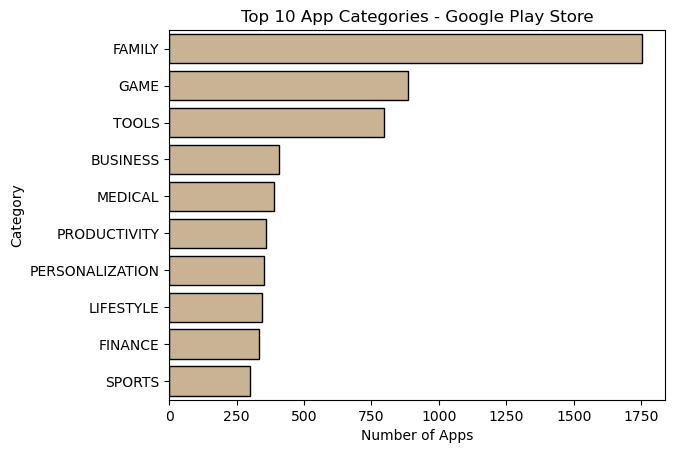

In [72]:
# Top Categories (Bar Chart)
top_categories = google_df['Category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index,color='tan',edgecolor='black')
plt.title("Top 10 App Categories - Google Play Store")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

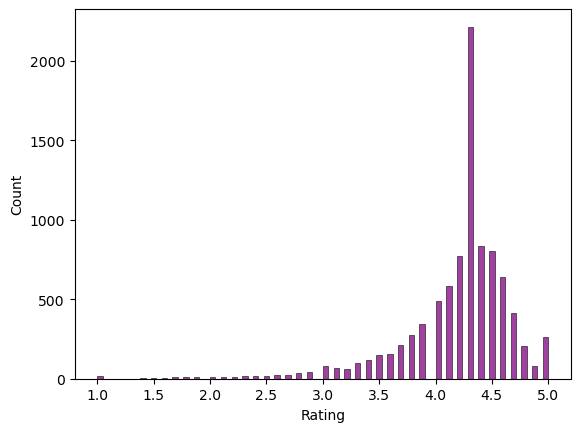

In [76]:
# Rating distribution 
sns.histplot(data=google_df,x='Rating',color='purple')
plt.show()

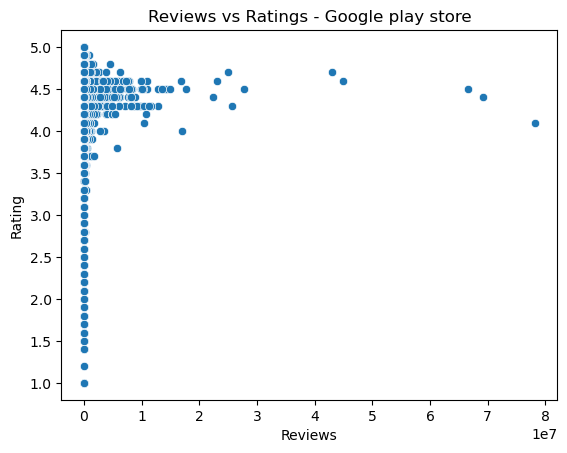

In [77]:
# Reviews vs ratings
sns.scatterplot(data=google_df,x='Reviews',y='Rating')
plt.title('Reviews vs Ratings - Google play store')
plt.show()

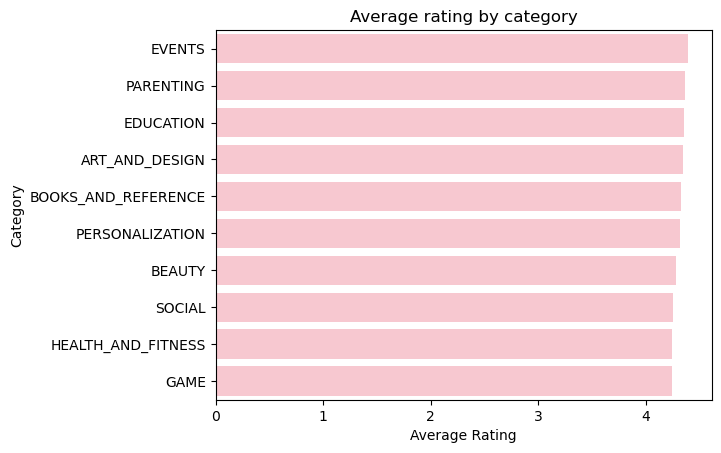

In [80]:
# Average rating by category
avg_rating = google_df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x= avg_rating.values,y= avg_rating.index,color = 'pink')
plt.title('Average rating by category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()